In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


H = np.eye(2) * 0.5
M = np.eye(2)
C = np.eye(2)
D = np.eye(2)
R = np.eye(2)
sigma = np.eye(2) * 0.3
T = 1.0

***Exercise1.1***

In [ ]:
#Excercise 1.1: Linear quadratic regulator
class LQRSolver:
    """
    Linear Quadratic Regulator (LQR) problems
    1. solving Riccati ODE
    2. provide def for v(t,x) and a(t,x)
    """
    #Exercise 1.1(1)
    def __init__(self, H, M, C, D, R, sigma, T):
        """
        C ≥ 0, R ≥ 0 and D > 0, are given and deterministic and we will assume 2 × 2
        2 spatial and 2 control dimensions, so X and α have two dimensions

        we know that sigma, H and M are 2 times 2 matrix

        """
        # Convert all inputs to numpy arrays and store
        self.H = np.array(H, dtype=np.float64)
        self.M = np.array(M, dtype=np.float64)
        self.C = np.array(C, dtype=np.float64)
        self.D = np.array(D, dtype=np.float64)
        self.R = np.array(R, dtype=np.float64)
        self.sigma = np.array(sigma, dtype=np.float64)
        self.T = float(T)

        assert self.H.shape == (2, 2), "H must be 2x2"
        assert self.M.shape == (2, 2), "M must be 2x2"
        assert self.C.shape == (2, 2), "C must be 2x2"
        assert self.D.shape == (2, 2), "D must be 2x2"
        assert self.R.shape == (2, 2), "R must be 2x2"
        assert self.sigma.shape == (2, 2), "sigma must be 2x2"
        assert self.T > 0, "Terminal time T must be positive"

        # Device and dtype settings
        self.dtype = torch.float32
        self.device = torch.device('cpu')

        # inverse D
        self.D_inv = np.linalg.inv(self.D)
        self.M_D_inv_MT = self.M @ self.D_inv @ self.M.T
        self.sigma_sigma_T = torch.as_tensor(self.sigma @ self.sigma.T, dtype=self.dtype, device=self.device)

        # Solution storage
        self.S_solution = None
        self.time_grid = None
        self.cumulative_integral = None
    
    #Exercice 1.1(2)
    def solve_riccati_ode(self, time_grid):
        """Core: solve ODE S(t)"""
        
        def riccati_rhs(r, S_flat):
            """ODE right hand side"""
            # vector → matrix
            S = S_flat.reshape(2, 2)
            
            # 
            dS = (-2 * self.H.T @ S + S @ self.M_D_inv_MT @ S - self.C)
            
            # matrix → vector
            return dS.flatten()
        
        # terminal
        S_T = self.R.flatten()
        
        # solve ODE（from T to 0, so y(0) = 1 and inverse time grid needed）
        solution = solve_ivp(riccati_rhs, [self.T, 0], S_T, t_eval=time_grid[::-1], method='RK45')
        
        # After transpose and reverse:
        # Each row: flattened S matrix at one time point
        # Each column: one matrix element across all time points
        self.S_solution = torch.as_tensor(
        solution.y.T[::-1].copy().reshape(-1, 2, 2),
        dtype=self.dtype,
        device=self.device)

        self.time_grid = torch.as_tensor(time_grid, dtype=self.dtype, device=self.device)
        # This is no relationship with riccati or derivative S. we just want to calculate the integral for the value function
        self._precompute_integral()

  
    def _precompute_integral(self):
        """
        Precompute ∫_t^T tr(σσ^T S(r)) dr for all t in time_grid.
        """
        N = len(self.time_grid)
        
        # Compute tr(σσ^T S(t)) for all t
        traces = torch.zeros(N, dtype=self.dtype, device=self.device)
        for i in range(N):
            traces[i] = torch.trace(self.sigma_sigma_T @ self.S_solution[i])
        
        # Cumulative integral from t to T (backward accumulation)
        self.cumulative_integral = torch.zeros(N, dtype=self.dtype, device=self.device)
        self.cumulative_integral[-1] = 0.0  # At T, integral = 0
        
        # Trapezoidal rule, backward
        for i in range(N - 2, -1, -1):
            dt = self.time_grid[i + 1] - self.time_grid[i]
            integral_step = 0.5 * dt * (traces[i] + traces[i + 1])
            self.cumulative_integral[i] = integral_step + self.cumulative_integral[i + 1]

        
    def interp_S_and_integral(self, t_batch: torch.Tensor):
        """
        Retrieve S(t) and integral term I(t).
        
        Args:
            t_batch: Time points, shape (batch_size,)
        
        Returns:
            S_t: Riccati matrices, shape (batch_size, 2, 2)
            I_t: Integral values, shape (batch_size,)
        """
        # Find nearest indices
        distances = torch.abs(t_batch.unsqueeze(1) - self.time_grid.unsqueeze(0))
        indices = torch.argmin(distances, dim=1)
        
        # Retrieve S(t) and I(t)
        S_t = self.S_solution[indices]
        I_t = self.cumulative_integral[indices]
        
        return S_t, I_t

    #Exercise1.1(3)
    def value_function(self, t_batch, x_batch):
        """
        Compute the value function v(t,x).
    
        Args:
        t_batch: Time points, shape (t_batch_size,)
        x_batch: State vectors, shape (batch_size ,1 ,2)
    
        Returns:
        torch.Tensor: Value function values, shape (batch_size, 1)
        
        """


            
        S_t, I_t = self.interp_S_and_integral(t_batch)
        quad = torch.bmm(torch.bmm(x_batch, S_t), x_batch.transpose(1, 2)).squeeze(-1)
        return quad + I_t.view(-1, 1)
    

    #Excercise1.1(4)
    def optimal_control(self, t_batch, x_batch):
        """
        compute a(t,x) - return torch.Tensor
        
        Args:
        t_batch: Time points, shape (t_batch_size,)
        x_batch: State vectors, shape (batch_size ,1 ,2)

        Returns:
        torch.Tensor: Value function values, shape (batch_size, 2)
        
        """
        t_batch = torch.as_tensor(t_batch, dtype=self.dtype, device=self.device).flatten()
        x_batch = torch.as_tensor(x_batch, dtype=self.dtype, device=self.device)

        S_t, _ = self.interp_S_and_integral(t_batch)
        x_col = x_batch.transpose(1, 2)  # (batch, 2, 1)
        Sx = torch.bmm(S_t, x_col)       # (batch, 2, 1)

        #parameters, adding a new dimension, lead K(2,2) to K(1,2,2) by unsqueeze(0)
        #copy them into 3 same vectors by expand(3, -1, -1)
        K = torch.as_tensor(-self.D_inv @ self.M.T, dtype=self.dtype, device=self.device)
        K_batch = K.unsqueeze(0).expand(x_batch.shape[0], -1, -1)
        a = torch.bmm(K_batch, Sx).squeeze(-1)
        return a

***exercise1.2***

[convergence_timesteps] scheme=explicit, n_paths=100000, K=100
  N=    1  v=3.30111  MSE=1.271e+01  Bias^2=1.271e+01  Var=3.280e-07
  N=   10  v=3.30111  MSE=2.373e-02  Bias^2=2.373e-02  Var=5.843e-06
  N=   50  v=3.30111  MSE=8.155e-04  Bias^2=8.085e-04  Var=6.945e-06
  N=  100  v=3.30111  MSE=1.951e-04  Bias^2=1.879e-04  Var=7.183e-06
  N=  500  v=3.30111  MSE=1.390e-05  Bias^2=6.451e-06  Var=7.447e-06
  N= 1000  v=3.30111  MSE=6.853e-06  Bias^2=5.833e-07  Var=6.269e-06
  N= 5000  v=3.30111  MSE=7.568e-06  Bias^2=3.188e-09  Var=7.565e-06


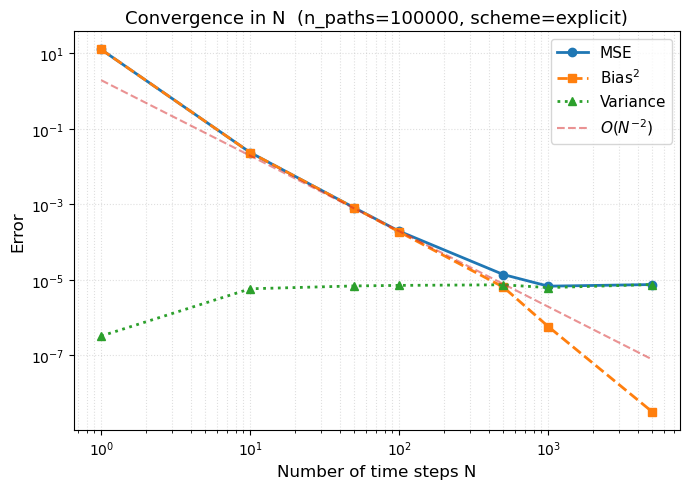

[convergence_samples] scheme=explicit, N=5000, K=100
  n_paths=     10  v=3.30111  MSE=6.326e-02  Bias^2=1.381e-04  Var=6.312e-02
  n_paths=     50  v=3.30111  MSE=1.559e-02  Bias^2=4.293e-05  Var=1.554e-02
  n_paths=    100  v=3.30111  MSE=5.973e-03  Bias^2=8.954e-05  Var=5.884e-03
  n_paths=    500  v=3.30111  MSE=1.216e-03  Bias^2=2.456e-07  Var=1.215e-03
  n_paths=   1000  v=3.30111  MSE=7.586e-04  Bias^2=2.026e-06  Var=7.566e-04
  n_paths=   5000  v=3.30111  MSE=1.144e-04  Bias^2=7.282e-08  Var=1.143e-04
  n_paths=  10000  v=3.30111  MSE=7.763e-05  Bias^2=3.982e-12  Var=7.763e-05
  n_paths=  50000  v=3.30111  MSE=1.040e-05  Bias^2=5.624e-08  Var=1.034e-05
  n_paths= 100000  v=3.30111  MSE=6.449e-06  Bias^2=2.506e-10  Var=6.449e-06


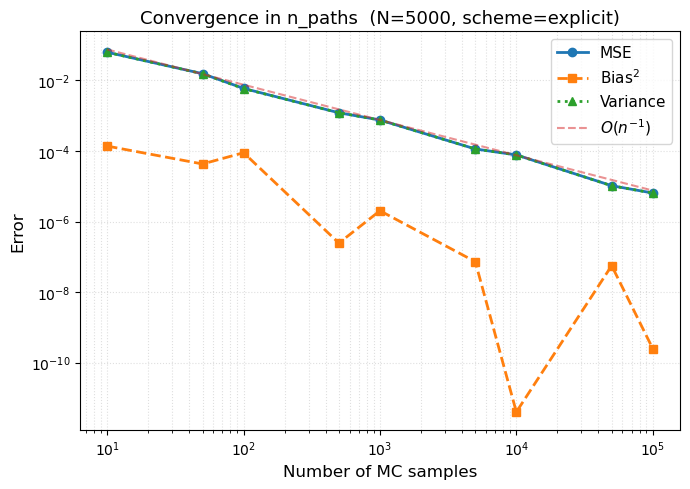

In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

class LQRMonteCarlo:
    """
    Exercise 1.2: Monte Carlo checks for LQR optimal control.

    Error measure (1.2.1):
        error = |mean_MC(J^alpha) - v(t0, x0)|

    Justification: v(t,x) = E^{t,x}[J^{alpha*}] exactly under the optimal
    control alpha* = a(t,x) = -D^{-1}M^T S(t)x.  By the law of large numbers
    the MC average converges to v(t,x) as n_paths -> inf.  Time discretisation
    introduces a (deterministic) bias that vanishes as N -> inf.
    The absolute error separates both sources of error cleanly and has the same
    units as the value function, making it easy to interpret.

    Reads from LQRSolver (Exercise 1.1):
        - solver.interp_S_and_integral(t_batch)  -> S(t), integral term
        - solver.value_function(t_batch, x_batch) -> v(t, x)
        - solver.H, M, C, D, R, sigma, D_inv, T
    """

    def __init__(self, solver: LQRSolver):
        self.solver = solver
        dtype, device = solver.dtype, solver.device
        self.dtype, self.device = dtype, device
        self.T = solver.T

        self.H     = torch.as_tensor(solver.H,     dtype=dtype, device=device)
        self.M     = torch.as_tensor(solver.M,     dtype=dtype, device=device)
        self.C     = torch.as_tensor(solver.C,     dtype=dtype, device=device)
        self.D     = torch.as_tensor(solver.D,     dtype=dtype, device=device)
        self.R     = torch.as_tensor(solver.R,     dtype=dtype, device=device)
        self.sigma = torch.as_tensor(solver.sigma, dtype=dtype, device=device)

        #substitude alpha into dXs, and calculate parameter M*-D_inverse*M.T
        # trans D_inv to be a tensor variable
        D_inv = torch.as_tensor(solver.D_inv, dtype=dtype, device=device)
        self.K  = -(D_inv @ self.M.T)   # (2,2)
        # MK = M K = -M D^{-}1 M^T  so that  A(t) = H + MK S(t)
        self.MK = self.M @ self.K       # (2,2)

    # Core simulation
    def simulate(self, N: int, n_paths: int, t0: float, x0,
                 scheme: str = 'explicit') -> float:
        """
        Simulate n_paths trajectories of the optimally-controlled SDE and
        return the sample mean cost.

        Explicit scheme (from sheet eq. above):
            X_{n+1} = X_n + tau * A(t_n) X_n + sigma * dW_n

        Implicit scheme (from sheet):
            (I - tau * A(t_{n+1})) X_{n+1} = X_n + sigma * dW_n

        where A(t) = H - M D^{-1} M^T S(t)  and  dW_n ~ N(0, tau * I_2).

        Args:
            N       : number of time steps
            n_paths : number of MC paths
            t0      : start time  (must be a grid point used in solve_riccati_ode)
            x0      : start state, array-like of shape (2,)
            scheme  : 'explicit' or 'implicit'

        Returns:
            float: sample mean of J^alpha over n_paths paths
        """
        # tau = T/N per sheet definition; N steps from t0 to T with this fixed step size
        tau  = self.T / N
        times = torch.linspace(t0, self.T, N + 1, dtype=self.dtype, device=self.device)

        # precompute S(t_n) and drift matrix A(t_n) for all n -------
        S_all, _ = self.solver.interp_S_and_integral(times)   # (N+1, 2, 2)

        #substitude alpha into dXs, we get a [H +M(-D_inverse*M_Transpose*S(t))x]ds + sigma*dws s in(t,T)
        # A(t_n) = H + MK @ S(t_n)
        A_all  = self.H.unsqueeze(0) + torch.einsum('ij,njk->nik', self.MK, S_all)
        # KS_all[n] = K @ S(t_n)  ->  a_n = X @ KS_all[n].T
        KS_all = torch.einsum('ij,njk->nik', self.K, S_all)   # (N+1, 2, 2)


        # Xn+1 = [(I−τAt(n+1​))X(n+1)]_inverse(Xn + sigma delta W）
        if scheme == 'implicit':
            I2 = torch.eye(2, dtype=self.dtype, device=self.device)
            # Precompute (I - tau * A(t_{n+1}))^{-1} for n+1 = 1..N
            LHS_inv_all = torch.linalg.inv(I2 - tau * A_all)  # (N+1, 2, 2)

        # --- initialise paths ------------------------------------------
        x0_t = torch.as_tensor(np.asarray(x0, dtype=np.float32),
                                dtype=self.dtype, device=self.device)
        X    = x0_t.unsqueeze(0).expand(n_paths, -1).contiguous()  # (n_paths, 2)
        cost = torch.zeros(n_paths, dtype=self.dtype, device=self.device)

        sigma_T  = self.sigma.T   # (2,2)
        #In order to allow Z follows N(0, tao)
        sqrt_tau = float(tau) ** 0.5

        # --- time-stepping loop ----------------------------------------
        for n in range(N):
            # Brownian increment: sigma * dW,  dW ~ N(0, tau * I_2)
            dW    = torch.randn(n_paths, 2, dtype=self.dtype, device=self.device)
            noise = sqrt_tau * (dW @ sigma_T)             # (n_paths, 2)

            # Running cost: tau * (X_n^T C X_n + a_n^T D a_n)
            a_n   = X @ KS_all[n].T                              # (n_paths, 2)
            X_col = X.unsqueeze(2)                               # (n_paths, 2, 1)
            a_col = a_n.unsqueeze(2)                             # (n_paths, 2, 1)
            C_batch = self.C.unsqueeze(0).expand(n_paths, -1, -1)
            D_batch = self.D.unsqueeze(0).expand(n_paths, -1, -1)
            xCx = torch.bmm(X.unsqueeze(1), torch.bmm(C_batch, X_col)).squeeze()   # X^T C X
            aDa = torch.bmm(a_n.unsqueeze(1), torch.bmm(D_batch, a_col)).squeeze()  # a^T D a
            cost += tau * (xCx + aDa)

            # State update
            if scheme == 'explicit':
                X = X + tau * (X @ A_all[n].T) + noise
            else:   # implicit
                X = (X + noise) @ LHS_inv_all[n + 1].T

        # Terminal cost: X_T^T R X_T
        X_col   = X.unsqueeze(2)                                 # (n_paths, 2, 1)
        R_batch = self.R.unsqueeze(0).expand(n_paths, -1, -1)
        cost += torch.bmm(X.unsqueeze(1), torch.bmm(R_batch, X_col)).squeeze()

        return cost.mean().item()

  
    
    # Error helper: MSE decomposed into Bias^2 and Variance via K independent MC runs

    def compute_error(self, N: int, n_paths: int, t0: float, x0,
                      scheme: str = 'explicit', K: int = 10):
        """
        Run K independent MC experiments and return MSE decomposition.

        MSE = Bias^2 + Variance
        where:
            Bias^2   = (mean(J_hat) - v)^2     <- discretisation error, fixed for fixed N
            Variance = mean((J_hat - mean(J_hat))^2)  <- sampling error, shrinks as 1/n

        Returns:
            mse      : Bias^2 + Variance
            bias2    : (mean(J_hat) - v_true)^2
            variance : sample variance of the K estimates
            v_true   : exact value function from Exercise 1.1
        """
        t_t    = torch.tensor([t0], dtype=self.dtype, device=self.device)
        x_t    = torch.tensor([[list(x0)]], dtype=self.dtype, device=self.device)
        v_true = self.solver.value_function(t_t, x_t).item()

        estimates = np.array([self.simulate(N, n_paths, t0, x0, scheme) for _ in range(K)])

        mean_est = estimates.mean()

        # Var(J_hat_k) = Var(J^N) / n, estimated from K independent runs
        var_J_hat = ((estimates - mean_est) ** 2).sum() / (K - 1)  # unbiased sample variance of J_hat_k

        # Bias^2: squared deviation of the K-run mean from the true value.
        # With K=120 independent runs the mean is precise enough that the var_J_bar
        # correction (= var_J_hat / K) is negligible, and its max-clipping would
        # artificially produce a downward-sloping bias2 in the n_paths experiment
        # (where true discretisation bias ~0 causes the corrected value to oscillate
        # around 0 and get clipped). Using the raw squared deviation avoids this.
        bias2    = (mean_est - v_true) ** 2
        variance = var_J_hat   # Var(J^N / n) = Var of one MC estimate with n paths
        mse      = bias2 + variance

        return mse, bias2, variance, v_true

  
    # Exercise 1.2.2 – vary N (time steps), fix n_paths


    def convergence_timesteps(self, n_paths: int, t0: float, x0,
                               N_list, scheme: str = 'explicit', K: int = 10):
        """
        Fix n_paths (e.g. 1e5), vary N in N_list = [1, 10, 50, 100, 500, 1000, 5000].

        Returns:
            N_arr     : np.ndarray of N values
            mse_arr   : np.ndarray of MSE
            bias2_arr : np.ndarray of Bias^2
            var_arr   : np.ndarray of Variance
        """
        print(f"[convergence_timesteps] scheme={scheme}, n_paths={n_paths}, K={K}")
        mse_list, bias2_list, var_list = [], [], []
        for N in N_list:
            mse, bias2, var, v = self.compute_error(N, n_paths, t0, x0, scheme, K)
            print(f"  N={N:5d}  v={v:.5f}  MSE={mse:.3e}  Bias^2={bias2:.3e}  Var={var:.3e}")
            mse_list.append(mse); bias2_list.append(bias2); var_list.append(var)
        return (np.array(N_list, dtype=float),
                np.array(mse_list), np.array(bias2_list), np.array(var_list))


    # Exercise 1.2.3 – vary n_paths (MC samples), fix N


    def convergence_samples(self, N: int, t0: float, x0,
                             n_paths_list, scheme: str = 'explicit', K: int = 10):
        """
        Fix N (e.g. 5000), vary n_paths in
        n_paths_list = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000].

        Returns:
            n_paths_arr: np.ndarray
            mse_arr    : np.ndarray of MSE
            bias2_arr  : np.ndarray of Bias^2  (should be ~constant, N is fixed)
            var_arr    : np.ndarray of Variance (should decay as O(1/n))
        """
        print(f"[convergence_samples] scheme={scheme}, N={N}, K={K}")
        mse_list, bias2_list, var_list = [], [], []
        for n_paths in n_paths_list:
            mse, bias2, var, v = self.compute_error(N, n_paths, t0, x0, scheme, K)
            print(f"  n_paths={n_paths:7d}  v={v:.5f}  MSE={mse:.3e}  Bias^2={bias2:.3e}  Var={var:.3e}")
            mse_list.append(mse); bias2_list.append(bias2); var_list.append(var)
        return (np.array(n_paths_list, dtype=float),
                np.array(mse_list), np.array(bias2_list), np.array(var_list))

    # Plotting utility
  

    @staticmethod
    def plot_convergence(x_vals, mse, bias2, variance, xlabel, title,
                         reference_slopes=None, save_path=None):
        """
        Log-log convergence plot showing MSE decomposed into Bias^2 and Variance.

        Args:
            x_vals           : x-axis values (N or n_paths)
            mse              : total MSE = Bias^2 + Variance
            bias2            : squared bias array
            variance         : variance array
            xlabel           : x-axis label string
            title            : plot title
            reference_slopes : list of (slope, label) for dashed reference lines
            save_path        : if given, save figure to this path
        """
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.loglog(x_vals, mse,      'o-', lw=2, ms=6, label='MSE')
        ax.loglog(x_vals, bias2,    's--', lw=2, ms=6, label=r'Bias$^2$')
        ax.loglog(x_vals, variance, '^:', lw=2, ms=6, label='Variance')

        if reference_slopes:
            mid = len(x_vals) // 2
            for slope, label in reference_slopes:
                y_ref = mse[mid] * (x_vals / x_vals[mid]) ** slope
                ax.loglog(x_vals, y_ref, '--', alpha=0.5, label=label)

        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel('Error', fontsize=12)
        ax.set_title(title, fontsize=13)
        ax.legend(fontsize=11)
        ax.grid(True, which='both', ls=':', alpha=0.4)
        plt.tight_layout()

        if save_path:
            fig.savefig(save_path, dpi=150)

        return fig



# Demo / main


if __name__ == '__main__':
    # ---- 1. Build and solve the LQR problem (Exercise 1.1) -----------
    H     = np.eye(2) * 0.5
    M     = np.eye(2)
    C     = np.eye(2)
    D     = np.eye(2)
    R     = np.eye(2)
    sigma = np.eye(2) * 0.3
    T     = 1.0

    solver = LQRSolver(H, M, C, D, R, sigma, T)
    # Use a fine grid so the Riccati ODE is accurate enough for large N
    solver.solve_riccati_ode(np.linspace(0, T, 10_000))

    mc = LQRMonteCarlo(solver)

    t0 = 0.0
    x0 = [1.0, 1.0]
    scheme = 'explicit'

    # ---- 2. Exercise 1.2.2: vary N, fix n_paths = 1e5 ---------------
    N_list        = [1, 10, 50, 100, 500, 1000, 5000]
    n_paths_fixed = 100_000

    N_arr, mse_N, bias2_N, var_N = mc.convergence_timesteps(n_paths_fixed, t0, x0, N_list, scheme, K=100)
    fig1 = LQRMonteCarlo.plot_convergence(
        N_arr, mse_N, bias2_N, var_N,
        xlabel='Number of time steps N',
        title=f'Convergence in N  (n_paths={n_paths_fixed}, scheme={scheme})',
        reference_slopes=[(-2, r'$O(N^{-2})$')]# since  bias
    )
    plt.show(block=False)

    # ---- 3. Exercise 1.2.3: vary n_paths, fix N = 5000 --------------
    n_paths_list = [10, 50, 100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
    N_fixed      = 5000

    np_arr, mse_np, bias2_np, var_np = mc.convergence_samples(N_fixed, t0, x0, n_paths_list, scheme, K=100)
    fig2 = LQRMonteCarlo.plot_convergence(
        np_arr, mse_np, bias2_np, var_np,
        xlabel='Number of MC samples',
        title=f'Convergence in n_paths  (N={N_fixed}, scheme={scheme})',
        reference_slopes=[(-1, r'$O(n^{-1})$')]
    )
    plt.show()


**Neural Networks**

In [4]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'


def set_seed(seed: int = 0):
    np.random.seed(seed)
    torch.manual_seed(seed)


def quadratic_form(x: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
    """Return x^T A x for a batch of row-vectors x with shape (batch, 2)."""
    return torch.einsum('bi,ij,bj->b', x, A, x)


def prepare_input(t: torch.Tensor, x: torch.Tensor, T: float, x_bound: float) -> torch.Tensor:
    if t.dim() == 1:
        t = t.unsqueeze(1)
    t_scaled = 2.0 * t / T - 1.0
    x_scaled = x / x_bound
    return torch.cat([t_scaled, x_scaled], dim=1)


class FFN(nn.Module):
    """Simple fully-connected network for policies or controls."""

    def __init__(self, input_dim=3, output_dim=2, hidden_dims=(100, 100), T=1.0, x_bound=3.0):
        super().__init__()
        self.T = float(T)
        self.x_bound = float(x_bound)

        dims = [input_dim] + list(hidden_dims) + [output_dim]
        layers = []
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        inputs = prepare_input(t, x, self.T, self.x_bound)
        return self.net(inputs)


class DGMLayer(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        self.U_z = nn.Linear(input_dim, hidden_dim)
        self.W_z = nn.Linear(hidden_dim, hidden_dim, bias=False)

        self.U_g = nn.Linear(input_dim, hidden_dim)
        self.W_g = nn.Linear(hidden_dim, hidden_dim, bias=False)

        self.U_r = nn.Linear(input_dim, hidden_dim)
        self.W_r = nn.Linear(hidden_dim, hidden_dim, bias=False)

        self.U_h = nn.Linear(input_dim, hidden_dim)
        self.W_h = nn.Linear(hidden_dim, hidden_dim, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor, s: torch.Tensor) -> torch.Tensor:
        z = torch.sigmoid(self.U_z(x) + self.W_z(s))
        g = torch.sigmoid(self.U_g(x) + self.W_g(s))
        r = torch.sigmoid(self.U_r(x) + self.W_r(s))
        h = torch.tanh(self.U_h(x) + self.W_h(s * r))
        return (1.0 - g) * h + z * s


class DGMNet(nn.Module):
    """DGM-style value network u(t, x)."""

    def __init__(self, input_dim=3, hidden_dim=100, n_layers=3, output_dim=1, T=1.0, x_bound=3.0):
        super().__init__()
        self.T = float(T)
        self.x_bound = float(x_bound)
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.dgm_layers = nn.ModuleList([DGMLayer(input_dim, hidden_dim) for _ in range(n_layers)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.input_layer.weight)
        nn.init.zeros_(self.input_layer.bias)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        inputs = prepare_input(t, x, self.T, self.x_bound)
        s = torch.tanh(self.input_layer(inputs))
        for layer in self.dgm_layers:
            s = layer(inputs, s)
        return self.output_layer(s)

**Exercise2.1**

[Exercise 2.1] step=    1  train_loss=9.7899e+01  val_loss=9.1338e+01
[Exercise 2.1] step=  250  train_loss=1.1074e-01  val_loss=1.1841e-01
[Exercise 2.1] step=  500  train_loss=4.7169e-02  val_loss=6.7219e-02
[Exercise 2.1] step=  750  train_loss=3.8487e-02  val_loss=5.0570e-02
[Exercise 2.1] step= 1000  train_loss=3.1899e-02  val_loss=3.5271e-02
[Exercise 2.1] step= 1250  train_loss=2.2189e-02  val_loss=2.4605e-02
[Exercise 2.1] step= 1500  train_loss=1.0460e-02  val_loss=9.9000e-03
[Exercise 2.1] step= 1750  train_loss=2.4520e-03  val_loss=4.5145e-03
[Exercise 2.1] step= 2000  train_loss=1.8901e-03  val_loss=3.2081e-03
[Exercise 2.1] step= 2250  train_loss=1.3213e-03  val_loss=3.2655e-03
[Exercise 2.1] step= 2500  train_loss=1.8475e-03  val_loss=1.9813e-03
[Exercise 2.1] step= 2750  train_loss=1.3901e-03  val_loss=1.7222e-03
[Exercise 2.1] step= 3000  train_loss=1.0298e-03  val_loss=1.5133e-03


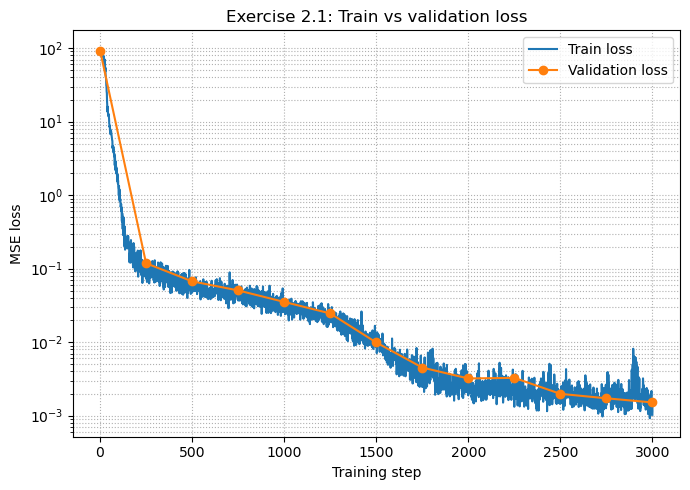

In [ ]:
class Exercise21ValueSupervised:
    """
    Exercise 2.1:
    Supervised learning of the value function using a DGM network.
  
    """

    def __init__(self, H, M, C, D, R, sigma, T, x_bound=3.0, hidden_dim=100,
                 n_dgm_layers=3, lr=1e-3, riccati_grid_size=10000,
                 dtype=torch.float32, device=None, seed=0):
        set_seed(seed)
        device = device or torch.device('cpu')

        self.dtype = dtype
        self.device = device
        self.T = float(T)
        self.x_bound = float(x_bound)

        self.solver = LQRSolver(H, M, C, D, R, sigma, T)
        self.solver.solve_riccati_ode(np.linspace(0.0, self.T, riccati_grid_size))

        self.value_net = DGMNet(
            input_dim=3,
            hidden_dim=hidden_dim,
            n_layers=n_dgm_layers,
            output_dim=1,
            T=self.T,
            x_bound=self.x_bound,
        ).to(device)

        self.optimizer = torch.optim.Adam(self.value_net.parameters(), lr=lr)
        self.history = {
            'step': [],
            'train_loss': [],
            'val_step': [],
            'val_loss': [],
        }
        self._validation_cache = None

    def sample_batch(self, batch_size: int):
        #random sampling
        t = torch.rand(batch_size, 1, dtype=self.dtype, device=self.device) * self.T
        x = (2.0 * torch.rand(batch_size, 2, dtype=self.dtype, device=self.device) - 1.0) * self.x_bound
        return t, x

    def exact_value(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        #upload data's signiture
        with torch.no_grad():
            target = self.solver.value_function(t.squeeze(1), x.unsqueeze(1)).squeeze(1)
        return target

    def make_validation_set(self, n_val: int = 1024):
        t_val, x_val = self.sample_batch(n_val)
        v_val = self.exact_value(t_val, x_val)
        self._validation_cache = {
            't': t_val.detach(),
            'x': x_val.detach(),
            'v': v_val.detach(),
        }
        return self._validation_cache

    def evaluate_validation_loss(self, n_val: int = 1024):
        if self._validation_cache is None or self._validation_cache['t'].shape[0] != n_val:
            self.make_validation_set(n_val)

        t_val = self._validation_cache['t']
        x_val = self._validation_cache['x']
        v_val = self._validation_cache['v']

        with torch.no_grad():
            pred = self.value_net(t_val, x_val).squeeze(1)
            mse = torch.mean((pred - v_val) ** 2).item()

        return mse

    def train(self, n_steps: int = 3000, batch_size: int = 512, eval_every: int = 250,
              val_size: int = 1024, verbose: bool = True):
        self.make_validation_set(val_size)

        #randomly sampling each loop and training
        for step in range(1, n_steps + 1):
            t_batch, x_batch = self.sample_batch(batch_size)
            target = self.exact_value(t_batch, x_batch).unsqueeze(1)

            self.optimizer.zero_grad()
            pred = self.value_net(t_batch, x_batch)
            train_loss = torch.mean((pred - target) ** 2)
            train_loss.backward()
            self.optimizer.step()

            self.history['step'].append(step)
            self.history['train_loss'].append(float(train_loss.item()))

            if step == 1 or step % eval_every == 0 or step == n_steps:
                val_loss = self.evaluate_validation_loss(val_size)
                self.history['val_step'].append(step)
                self.history['val_loss'].append(val_loss)

                if verbose:
                    print(
                        f"[Exercise 2.1] step={step:5d}  "
                        f"train_loss={train_loss.item():.4e}  "
                        f"val_loss={val_loss:.4e}"
                    )

        return self.history

    @staticmethod
    def plot_train_vs_validation_loss(history, save_path=None):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(history['step'], history['train_loss'], label='Train loss')
        ax.plot(history['val_step'], history['val_loss'], marker='o', label='Validation loss')
        ax.set_xlabel('Training step')
        ax.set_ylabel('MSE loss')
        ax.set_yscale('log')
        ax.set_title('Exercise 2.1: Train vs validation loss')
        ax.grid(True, which='both', ls=':')
        ax.legend()
        plt.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=150)
        return fig


if __name__ == '__main__':
    H = np.eye(2) * 0.5
    M = np.eye(2)
    C = np.eye(2)
    D = np.eye(2)
    R = np.eye(2)
    sigma = np.eye(2) * 0.3
    T = 1.0

    trainer = Exercise21ValueSupervised(
        H=H,
        M=M,
        C=C,
        D=D,
        R=R,
        sigma=sigma,
        T=T,
        x_bound=3.0,
        hidden_dim=100,
        n_dgm_layers=3,
        lr=1e-3,
        seed=0,
    )

    history = trainer.train(
        n_steps=3000,
        batch_size=512,
        eval_every=250,
        val_size=1024,
        verbose=True,
    )

    Exercise21ValueSupervised.plot_train_vs_validation_loss(history)


Explaination:

Since we use mini-batch gradient descent, at each training step only 512 randomly sampled points are used to compute the loss. Because each batch is different, the training loss has fluctuations, which explains the jagged appearance of the train loss curve.

The validation loss is smooth because the validation set is fixed — the same 1024 points are used every time, so there is no sampling noise.

More importantly, since the training points are randomly sampled from a continuous domain at every step, the network never sees the same batch twice and cannot memorise any fixed set of samples. This means there is no overfitting, and the validation loss follows the train loss down throughout training.

[Exercise 2.2] step=    1  train_loss=4.9105e+00  val_loss=4.8729e+00
[Exercise 2.2] step=  250  train_loss=1.2682e-02  val_loss=1.1071e-02
[Exercise 2.2] step=  500  train_loss=3.0439e-03  val_loss=3.0165e-03
[Exercise 2.2] step=  750  train_loss=3.0306e-03  val_loss=2.5379e-03
[Exercise 2.2] step= 1000  train_loss=2.4732e-03  val_loss=2.2102e-03
[Exercise 2.2] step= 1250  train_loss=2.0396e-03  val_loss=1.9493e-03
[Exercise 2.2] step= 1500  train_loss=2.2133e-03  val_loss=1.7199e-03
[Exercise 2.2] step= 1750  train_loss=1.6905e-03  val_loss=1.5501e-03
[Exercise 2.2] step= 2000  train_loss=1.4327e-03  val_loss=1.4025e-03
[Exercise 2.2] step= 2250  train_loss=1.2084e-03  val_loss=1.2433e-03
[Exercise 2.2] step= 2500  train_loss=1.2240e-03  val_loss=1.1479e-03
[Exercise 2.2] step= 2750  train_loss=1.0581e-03  val_loss=9.9751e-04
[Exercise 2.2] step= 3000  train_loss=9.0768e-04  val_loss=8.7074e-04


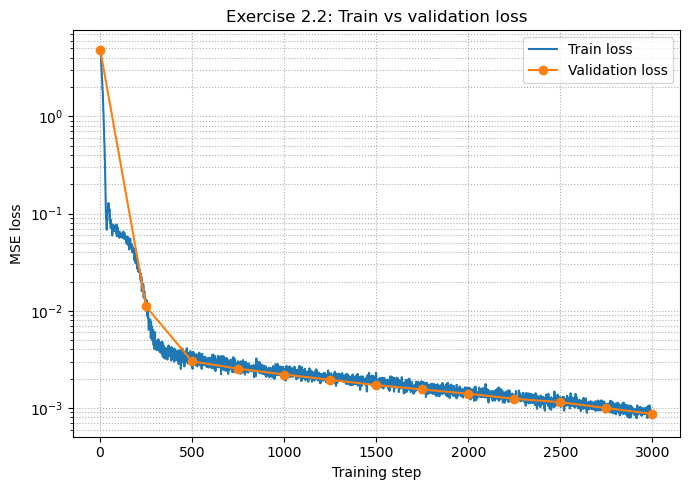

In [6]:
class Exercise22ControlSupervised:
    """
    Exercise 2.2:
    Supervised learning of the optimal Markov control using a feed-forward network.

    This version keeps only the train-vs-validation loss plot.
    
    """

    def __init__(self, H, M, C, D, R, sigma, T, x_bound=3.0,
                 hidden_dims=(100, 100), lr=1e-3, riccati_grid_size=10000,
                 dtype=torch.float32, device=None, seed=0):
        set_seed(seed)
        device = device or torch.device('cpu')

        self.dtype = dtype
        self.device = device
        self.T = float(T)
        self.x_bound = float(x_bound)

        self.solver = LQRSolver(H, M, C, D, R, sigma, T)
        self.solver.solve_riccati_ode(np.linspace(0.0, self.T, riccati_grid_size))

        self.control_net = FFN(
            input_dim=3,
            output_dim=2,
            hidden_dims=hidden_dims,
            T=self.T,
            x_bound=self.x_bound,
        ).to(device)

        #managing parameters upudating
        self.optimizer = torch.optim.Adam(self.control_net.parameters(), lr=lr)
        self.history = {
            'step': [],
            'train_loss': [],
            'val_step': [],
            'val_loss': [],
        }
        self._validation_cache = None

    def sample_batch(self, batch_size: int):
        t = torch.rand(batch_size, 1, dtype=self.dtype, device=self.device) * self.T
        x = (2.0 * torch.rand(batch_size, 2, dtype=self.dtype, device=self.device) - 1.0) * self.x_bound
        return t, x

    def exact_control(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            target = self.solver.optimal_control(t.squeeze(1), x.unsqueeze(1))
        return target

    def make_validation_set(self, n_val: int = 1024):
        t_val, x_val = self.sample_batch(n_val)
        a_val = self.exact_control(t_val, x_val)
        self._validation_cache = {
            't': t_val.detach(),
            'x': x_val.detach(),
            'a': a_val.detach(),
        }
        return self._validation_cache

    def evaluate_validation_loss(self, n_val: int = 1024):
        if self._validation_cache is None or self._validation_cache['t'].shape[0] != n_val:
            self.make_validation_set(n_val)

        t_val = self._validation_cache['t']
        x_val = self._validation_cache['x']
        a_val = self._validation_cache['a']

        with torch.no_grad():
            pred = self.control_net(t_val, x_val)
            mse = torch.mean((pred - a_val) ** 2).item()

        return mse

    def train(self, n_steps: int = 3000, batch_size: int = 512, eval_every: int = 250,
              val_size: int = 1024, verbose: bool = True):
        self.make_validation_set(val_size)

        for step in range(1, n_steps + 1):
            t_batch, x_batch = self.sample_batch(batch_size)
            target = self.exact_control(t_batch, x_batch)

            self.optimizer.zero_grad()
            pred = self.control_net(t_batch, x_batch)
            train_loss = torch.mean((pred - target) ** 2)
            train_loss.backward()
            self.optimizer.step()

            self.history['step'].append(step)
            self.history['train_loss'].append(float(train_loss.item()))

            if step == 1 or step % eval_every == 0 or step == n_steps:
                val_loss = self.evaluate_validation_loss(val_size)
                self.history['val_step'].append(step)
                self.history['val_loss'].append(val_loss)

                if verbose:
                    print(
                        f"[Exercise 2.2] step={step:5d}  "
                        f"train_loss={train_loss.item():.4e}  "
                        f"val_loss={val_loss:.4e}"
                    )

        return self.history

    @staticmethod
    def plot_train_vs_validation_loss(history, save_path=None):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(history['step'], history['train_loss'], label='Train loss')
        ax.plot(history['val_step'], history['val_loss'], marker='o', label='Validation loss')
        ax.set_xlabel('Training step')
        ax.set_ylabel('MSE loss')
        ax.set_yscale('log')
        ax.set_title('Exercise 2.2: Train vs validation loss')
        ax.grid(True, which='both', ls=':')
        ax.legend()
        plt.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=150)
        return fig


if __name__ == '__main__':
    H = np.eye(2) * 0.5
    M = np.eye(2)
    C = np.eye(2)
    D = np.eye(2)
    R = np.eye(2)
    sigma = np.eye(2) * 0.3
    T = 1.0

    trainer = Exercise22ControlSupervised(
        H=H,
        M=M,
        C=C,
        D=D,
        R=R,
        sigma=sigma,
        T=T,
        x_bound=3.0,
        hidden_dims=(100, 100),
        lr=1e-3,
        seed=0,
    )

    history = trainer.train(
        n_steps=3000,
        batch_size=512,
        eval_every=250,
        val_size=1024,
        verbose=True,
    )

    Exercise22ControlSupervised.plot_train_vs_validation_loss(history)


Explaination:
1.Instead of DGMNet, it uses an FFN with 2 hidden layers of size 100
2.Instead of learning V(t,x), it learns the optimal Markov control α(t,x), which is a 2-dimensional vector, so output_dim=2
3.The labels are computed from the Riccati solver via exact_control instead of exact_value

The training loop is identical — at each step, 512 points (t,x) are randomly sampled, the exact control is used as the target, and the network is updated by minimising MSE loss with Adam. Since the training points are re-sampled every step from a continuous domain, there is no overfitting, and the validation loss follows the train loss down throughout training, as seen in the loss curve above.

**Exercise 3**

[Exercise 3] step=    1  loss=1.2652e+02  eqn=7.5699e+01  boundary=5.0818e+01  mc_rmse=2.4055e+01
[Exercise 3] step=  200  loss=9.8880e-01  eqn=8.8359e-01  boundary=1.0521e-01  mc_rmse=6.5451e+00
[Exercise 3] step=  400  loss=2.0294e-01  eqn=1.5800e-01  boundary=4.4940e-02  mc_rmse=5.5603e+00
[Exercise 3] step=  600  loss=7.4387e-02  eqn=4.2588e-02  boundary=3.1799e-02  mc_rmse=5.0820e+00
[Exercise 3] step=  800  loss=7.3470e-02  eqn=4.7899e-02  boundary=2.5572e-02  mc_rmse=4.7785e+00
[Exercise 3] step= 1000  loss=4.6050e-02  eqn=2.6462e-02  boundary=1.9588e-02  mc_rmse=4.6131e+00
[Exercise 3] step= 1200  loss=2.7628e-02  eqn=1.1032e-02  boundary=1.6595e-02  mc_rmse=4.4355e+00
[Exercise 3] step= 1400  loss=2.4932e-02  eqn=1.0941e-02  boundary=1.3991e-02  mc_rmse=4.3241e+00
[Exercise 3] step= 1600  loss=1.3858e-02  eqn=6.1998e-03  boundary=7.6583e-03  mc_rmse=4.1518e+00
[Exercise 3] step= 1800  loss=1.5945e-02  eqn=5.8537e-03  boundary=1.0092e-02  mc_rmse=4.0869e+00
[Exercise 3] step= 2

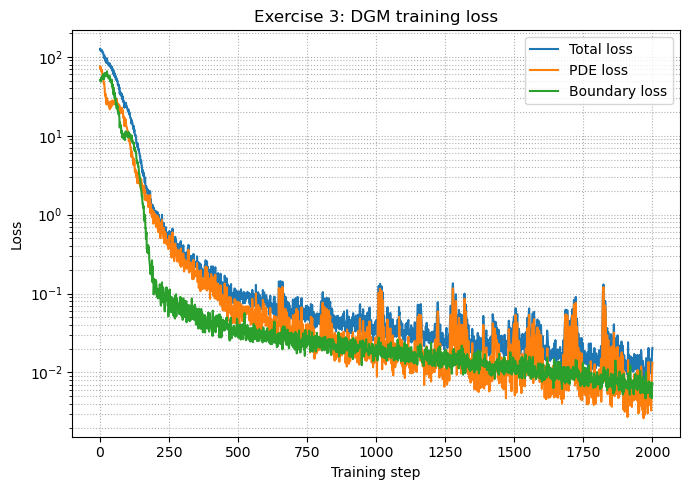

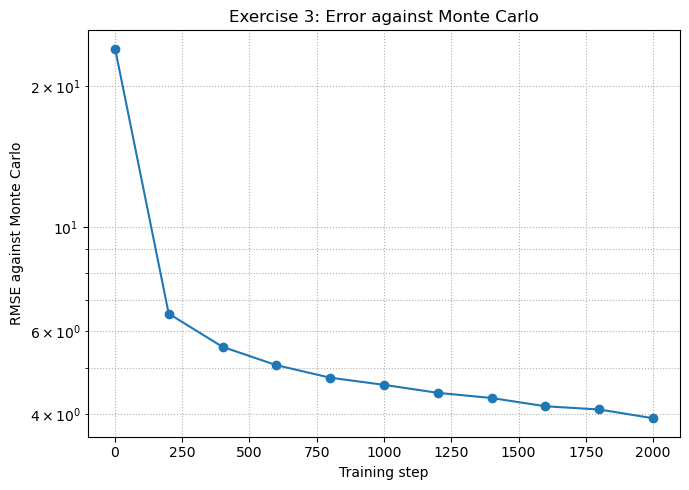

In [7]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

class LinearQuadraticPDEProblem:
    """
    Utility class shared by Exercise 3 and 4.
    compute PDE residual
    compute dgm loss 
    """

    def __init__(self, H, M, C, D, R, sigma, T, x_bound=3.0, dtype=torch.float32, device=None):
        device = device or torch.device('cpu')
        self.device = device
        self.dtype = dtype
        self.T = float(T)
        self.x_bound = float(x_bound)

        self.H = torch.as_tensor(H, dtype=dtype, device=device)
        self.M = torch.as_tensor(M, dtype=dtype, device=device)
        self.C = torch.as_tensor(C, dtype=dtype, device=device)
        self.D = torch.as_tensor(D, dtype=dtype, device=device)
        self.R = torch.as_tensor(R, dtype=dtype, device=device)
        self.sigma = torch.as_tensor(sigma, dtype=dtype, device=device)
        self.sigma_sigma_T = self.sigma @ self.sigma.T

    def sample_interior(self, batch_size: int):
        t = torch.rand(batch_size, 1, dtype=self.dtype, device=self.device) * self.T
        x = (2.0 * torch.rand(batch_size, 2, dtype=self.dtype, device=self.device) - 1.0) * self.x_bound
        return t, x

    def sample_terminal(self, batch_size: int):
        t = torch.full((batch_size, 1), self.T, dtype=self.dtype, device=self.device)
        x = (2.0 * torch.rand(batch_size, 2, dtype=self.dtype, device=self.device) - 1.0) * self.x_bound
        return t, x

    def terminal_cost(self, x: torch.Tensor) -> torch.Tensor:
        return quadratic_form(x, self.R).unsqueeze(1)

    def running_cost(self, x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        return (quadratic_form(x, self.C) + quadratic_form(a, self.D)).unsqueeze(1)

    def evaluate_policy(self, policy, t: torch.Tensor, x: torch.Tensor, detach_inputs: bool = False) -> torch.Tensor:
        t_in = t.detach() if detach_inputs else t
        x_in = x.detach() if detach_inputs else x

        if callable(policy):
            a = policy(t_in, x_in)
        else:
            a = torch.as_tensor(policy, dtype=self.dtype, device=self.device).view(1, 2).expand(x_in.shape[0], -1)

        if a.dim() == 3:
            a = a.squeeze(1)
        return a

    """
    The PDE residual measures how much the computed value function V deviates from satisfying the governing PDE. 
    The DGM loss quantifies the overall discrepancy, including both the PDE residual and the deviation from the terminal condition.
    
    """
    def pde_residual(self, value_net: nn.Module, policy, t: torch.Tensor, x: torch.Tensor, detach_policy: bool = True):
        t_req = t.clone().detach().requires_grad_(True)
        x_req = x.clone().detach().requires_grad_(True)

        u = value_net(t_req, x_req)
        u_t = torch.autograd.grad(u.sum(), t_req, create_graph=True)[0]
        grad_x = torch.autograd.grad(u.sum(), x_req, create_graph=True)[0]

        hessian_rows = []
        for i in range(2):
            grad_x_i = grad_x[:, i:i + 1]
            second = torch.autograd.grad(grad_x_i.sum(), x_req, create_graph=True)[0]
            hessian_rows.append(second.unsqueeze(1))
        hessian = torch.cat(hessian_rows, dim=1)

        diffusion = 0.5 * torch.einsum('ij,bij->b', self.sigma_sigma_T, hessian)
        a = self.evaluate_policy(policy, t_req, x_req, detach_inputs=detach_policy)
        drift = x_req @ self.H.T + a @ self.M.T
        running = self.running_cost(x_req, a).squeeze(1)
        residual = u_t.squeeze(1) + diffusion + torch.sum(grad_x * drift, dim=1) + running
        return residual.unsqueeze(1)

    def dgm_loss(self, value_net: nn.Module, policy, batch_size: int, boundary_batch_size: int = None,
                 boundary_weight: float = 1.0, detach_policy: bool = True):
        boundary_batch_size = boundary_batch_size or batch_size

        t_int, x_int = self.sample_interior(batch_size)
        residual = self.pde_residual(value_net, policy, t_int, x_int, detach_policy=detach_policy)
        eqn_loss = torch.mean(residual ** 2)

        t_T, x_T = self.sample_terminal(boundary_batch_size)
        u_T = value_net(t_T, x_T)
        target_T = self.terminal_cost(x_T)
        boundary_loss = torch.mean((u_T - target_T) ** 2)

        #loss function 
        total_loss = eqn_loss + boundary_weight * boundary_loss
        return total_loss, eqn_loss, boundary_loss


class ControlledSDEMonteCarlo:
    """
    Monte Carlo evaluator for a general Markov policy a(t, x).
    Given a fixed alpha, Using Monte Carlo calulate SDE in reality, get an estimated V

    """

    def __init__(self, problem: LinearQuadraticPDEProblem):
        self.problem = problem
        self.dtype = problem.dtype
        self.device = problem.device

    def simulate(self, policy, N: int, n_paths: int, t0: float, x0) -> float:
        tau = (self.problem.T - float(t0)) / N
        times = torch.linspace(float(t0), self.problem.T, N + 1, dtype=self.dtype, device=self.device)

        x0_t = torch.as_tensor(x0, dtype=self.dtype, device=self.device).view(1, 2)
        X = x0_t.expand(n_paths, -1).clone()
        total_cost = torch.zeros(n_paths, dtype=self.dtype, device=self.device)
        sigma_T = self.problem.sigma.T
        sqrt_tau = float(tau) ** 0.5

        for n in range(N):
            t_now = torch.full((n_paths, 1), float(times[n]), dtype=self.dtype, device=self.device)
            a_now = self.problem.evaluate_policy(policy, t_now, X, detach_inputs=True)
            total_cost += tau * (quadratic_form(X, self.problem.C) + quadratic_form(a_now, self.problem.D))
            drift = X @ self.problem.H.T + a_now @ self.problem.M.T
            noise = sqrt_tau * (torch.randn(n_paths, 2, dtype=self.dtype, device=self.device) @ sigma_T)
            X = X + tau * drift + noise

        total_cost += quadratic_form(X, self.problem.R)
        return total_cost.mean().item()

    def estimate_batch(self, policy, t_batch: torch.Tensor, x_batch: torch.Tensor, N: int, n_paths: int) -> torch.Tensor:
        estimates = []
        for i in range(t_batch.shape[0]):
            t0 = float(t_batch[i].item())
            x0 = x_batch[i].detach().cpu().numpy()
            estimates.append(self.simulate(policy, N=N, n_paths=n_paths, t0=t0, x0=x0))
        return torch.tensor(estimates, dtype=self.dtype, device=self.device)


class Exercise3LinearPDEDGM:

    """
    Exercise 3.1: DGM for the linear PDE with constant alpha = (1, 1)^T.
    
    Traing DGM network to solve PDE(alpha defined (1,1) at _init_())
    """

    def __init__(self, H, M, C, D, R, sigma, T, alpha=(1.0, 1.0), x_bound=3.0,
                 hidden_dim=100, n_dgm_layers=3, lr=1e-3, dtype=torch.float32, device=None, seed=0):
        set_seed(seed)
        device = device or torch.device('cpu')
        self.problem = LinearQuadraticPDEProblem(H, M, C, D, R, sigma, T, x_bound=x_bound, dtype=dtype, device=device)
        self.alpha = torch.as_tensor(alpha, dtype=dtype, device=device).view(1, 2)

        self.value_net = DGMNet(
            input_dim=3,
            hidden_dim=hidden_dim,
            n_layers=n_dgm_layers,
            output_dim=1,
            T=T,
            x_bound=x_bound,
        ).to(device)

        self.optimizer = torch.optim.Adam(self.value_net.parameters(), lr=lr)
        self.mc = ControlledSDEMonteCarlo(self.problem)
        self.history = {
            'step': [],
            'loss': [],
            'eqn_loss': [],
            'boundary_loss': [],
            'mc_eval_step': [],
            'mc_rmse': [],
        }
        self._test_cache = None

    def constant_policy(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        return self.alpha.expand(x.shape[0], -1)

    def make_test_set(self, n_test: int = 16):
        t_test, x_test = self.problem.sample_interior(n_test)
        self._test_cache = (t_test.detach(), x_test.detach())
        return self._test_cache

    def evaluate_against_mc(self, n_test: int = 16, mc_steps: int = 100, mc_paths: int = 1000):
        if self._test_cache is None or self._test_cache[0].shape[0] != n_test:
            self.make_test_set(n_test)

        t_test, x_test = self._test_cache
        with torch.no_grad():
            pred = self.value_net(t_test, x_test).squeeze(1)
        mc_val = self.mc.estimate_batch(self.constant_policy, t_test, x_test, N=mc_steps, n_paths=mc_paths)
        rmse = torch.sqrt(torch.mean((pred - mc_val) ** 2)).item()
        return rmse

    def train(self, n_steps: int = 5000, batch_size: int = 512, boundary_batch_size: int = None,
              boundary_weight: float = 1.0, eval_every: int = 250,
              mc_test_size: int = 16, mc_steps: int = 100, mc_paths: int = 1000,
              verbose: bool = True):
        boundary_batch_size = boundary_batch_size or batch_size

        for step in range(1, n_steps + 1):
            self.optimizer.zero_grad()
            total_loss, eqn_loss, boundary_loss = self.problem.dgm_loss(
                self.value_net,
                self.constant_policy,
                batch_size=batch_size,
                boundary_batch_size=boundary_batch_size,
                boundary_weight=boundary_weight,
                detach_policy=True,
            )
            total_loss.backward()
            self.optimizer.step()

            self.history['step'].append(step)
            self.history['loss'].append(float(total_loss.item()))
            self.history['eqn_loss'].append(float(eqn_loss.item()))
            self.history['boundary_loss'].append(float(boundary_loss.item()))

            if step == 1 or step % eval_every == 0 or step == n_steps:
                rmse = self.evaluate_against_mc(n_test=mc_test_size, mc_steps=mc_steps, mc_paths=mc_paths)
                self.history['mc_eval_step'].append(step)
                self.history['mc_rmse'].append(rmse)
                if verbose:
                    print(
                        f"[Exercise 3] step={step:5d}  "
                        f"loss={total_loss.item():.4e}  "
                        f"eqn={eqn_loss.item():.4e}  "
                        f"boundary={boundary_loss.item():.4e}  "
                        f"mc_rmse={rmse:.4e}"
                    )

        return self.history

    @staticmethod
    def plot_loss(history, save_path=None):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(history['step'], history['loss'], label='Total loss')
        ax.plot(history['step'], history['eqn_loss'], label='PDE loss')
        ax.plot(history['step'], history['boundary_loss'], label='Boundary loss')
        ax.set_xlabel('Training step')
        ax.set_ylabel('Loss')
        ax.set_yscale('log')
        ax.set_title('Exercise 3: DGM training loss')
        ax.grid(True, which='both', ls=':')
        ax.legend()
        plt.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=150)
        return fig

    @staticmethod
    def plot_mc_error(history, save_path=None):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(history['mc_eval_step'], history['mc_rmse'], marker='o')
        ax.set_xlabel('Training step')
        ax.set_ylabel('RMSE against Monte Carlo')
        ax.set_yscale('log')
        ax.set_title('Exercise 3: Error against Monte Carlo')
        ax.grid(True, which='both', ls=':')
        plt.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=150)
        return fig


if __name__ == '__main__':
    H = np.eye(2) * 0.5
    M = np.eye(2)
    C = np.eye(2)
    D = np.eye(2)
    R = np.eye(2)
    sigma = np.eye(2) * 0.3
    T = 1.0

    trainer = Exercise3LinearPDEDGM(
        H=H,
        M=M,
        C=C,
        D=D,
        R=R,
        sigma=sigma,
        T=T,
        alpha=(1.0, 1.0),
        x_bound=3.0,
        hidden_dim=100,
        n_dgm_layers=3,
        lr=1e-3,
        seed=0,
    )

    history = trainer.train(
        n_steps=2000,
        batch_size=512,
        boundary_batch_size=512,
        boundary_weight=1.0,
        eval_every=200,
        mc_test_size=16,
        mc_steps=200,
        mc_paths=1000,
        verbose=True,
    )

    Exercise3LinearPDEDGM.plot_loss(history)
    Exercise3LinearPDEDGM.plot_mc_error(history)


Explanation：
Exercise 3 fixes the policy $\alpha = [1,1]^T$ as a constant, which makes the HJB equation linear and guarantees a unique solution $V^\alpha$. The goal here is not to find the optimal policy, but to verify that the DGM network is capable of solving a PDE when $\alpha$ is known.

With $\alpha$ fixed, DGM is trained by minimising two terms: the PDE residual (how much the network output violates the HJB equation) and the boundary loss (how much the network output deviates from the terminal cost at $t=T$). Once these two conditions are satisfied, the network has learned $V^\alpha$ — the expected total cost under the fixed policy.

To validate the result, Monte Carlo simulation is used to estimate the true $V^\alpha$ by simulating SDE paths and accumulating costs. The RMSE between the DGM prediction and the Monte Carlo estimate is then plotted, as shown in the figure above. The decreasing RMSE confirms that DGM is able to recover $V^\alpha$ accurately given a fixed $\alpha$, which establishes the foundation for Exercise 4, where DGM is used inside a policy iteration loop.

***Exercise 4***

[Exercise 4] policy iteration 1/4
  value evaluation done: last loss = 6.4110e-02
  policy improvement done: last Hamiltonian = -6.0418e+00
  comparison to Exercise 1.1: value_rmse = 7.7539e+00, policy_rmse = 1.1780e+00
[Exercise 4] policy iteration 2/4
  value evaluation done: last loss = 2.2982e-01
  policy improvement done: last Hamiltonian = 3.2201e+00
  comparison to Exercise 1.1: value_rmse = 1.0483e+00, policy_rmse = 1.5745e-01
[Exercise 4] policy iteration 3/4
  value evaluation done: last loss = 2.0444e-02
  policy improvement done: last Hamiltonian = 3.2008e+00
  comparison to Exercise 1.1: value_rmse = 6.3023e-02, policy_rmse = 7.7833e-02
[Exercise 4] policy iteration 4/4
  value evaluation done: last loss = 8.6232e-03
  policy improvement done: last Hamiltonian = 3.1674e+00
  comparison to Exercise 1.1: value_rmse = 3.9210e-02, policy_rmse = 7.1441e-02


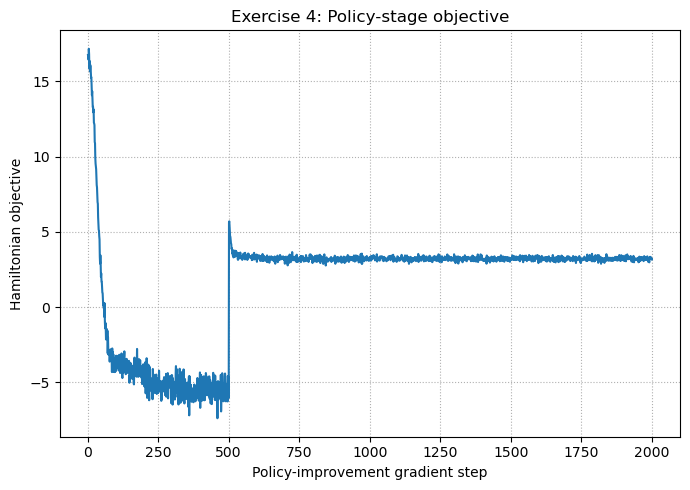

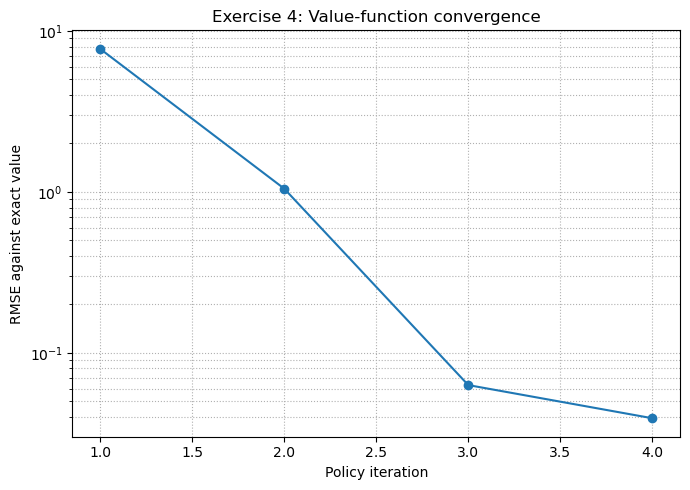

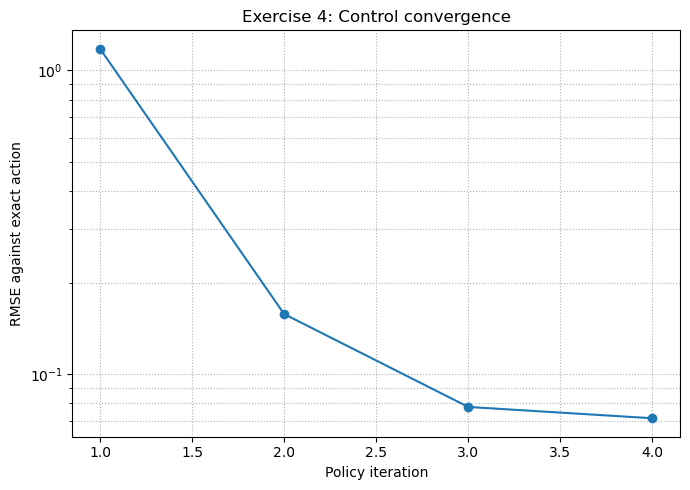

In [8]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'


class PolicyIterationDGM:
    """
    Exercise 4.1: Policy iteration with a DGM value network and FFN policy network.

    DGMNet(value_net): learning how to slove v, output = 1
    FNN(policy_net):learning how to solve α, output = 2
    
    """

    def __init__(self, H, M, C, D, R, sigma, T, exact_solver: LQRSolver,
                 x_bound=3.0, hidden_dim=100, n_dgm_layers=3, policy_hidden_dims=(100, 100),
                 value_lr=1e-3, policy_lr=1e-3, dtype=torch.float32, device=None, seed=0):
        set_seed(seed)
        device = device or torch.device('cpu')
        self.problem = LinearQuadraticPDEProblem(
            H, M, C, D, R, sigma, T, x_bound=x_bound, dtype=dtype, device=device
        )
        self.exact_solver = exact_solver
        self.device = device
        self.dtype = dtype

        self.value_net = DGMNet(
            input_dim=3,
            hidden_dim=hidden_dim,
            n_layers=n_dgm_layers,
            output_dim=1,
            T=T,
            x_bound=x_bound,
        ).to(device)

        self.policy_net = FFN(
            input_dim=3,
            output_dim=2,
            hidden_dims=policy_hidden_dims,
            T=T,
            x_bound=x_bound,
        ).to(device)
        self._initialise_policy_to_zero()

        self.value_optimizer = torch.optim.Adam(self.value_net.parameters(), lr=value_lr)
        self.policy_optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=policy_lr)

        self.history = {
            'value_stage_step': [],
            'value_stage_loss': [],
            'policy_stage_step': [],
            'policy_stage_loss': [],
            'pi_iter': [],
            'value_rmse': [],
            'policy_rmse': [],
        }
        self._test_cache = None


    def _initialise_policy_to_zero(self):
        last_linear = None
        for module in self.policy_net.modules():
            if isinstance(module, nn.Linear):
                last_linear = module
        if last_linear is not None:
            nn.init.zeros_(last_linear.weight)
            nn.init.zeros_(last_linear.bias)

    # exact_value & exact_action: the exact solution of the Riccati equation, used for comparison
    def exact_value(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            return self.exact_solver.value_function(t.squeeze(1), x.unsqueeze(1)).squeeze(1)

    def exact_action(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            return self.exact_solver.optimal_control(t.squeeze(1), x.unsqueeze(1))

    def make_test_set(self, n_test: int = 1024):
        t = torch.rand(n_test, 1, dtype=self.dtype, device=self.device) * self.problem.T
        x = (2.0 * torch.rand(n_test, 2, dtype=self.dtype, device=self.device) - 1.0) * self.problem.x_bound
        exact_v = self.exact_value(t, x)
        exact_a = self.exact_action(t, x)
        self._test_cache = {
            't': t.detach(),
            'x': x.detach(),
            'v': exact_v.detach(),
            'a': exact_a.detach(),
        }
        return self._test_cache
    """
    value_rmse: caluculate error between value_net and exact_value
    policy_rmse: caluculate error between policy net and exact_action

    """
    def value_rmse(self, n_test: int = 1024) -> float:
        if self._test_cache is None or self._test_cache['t'].shape[0] != n_test:
            self.make_test_set(n_test)
        t = self._test_cache['t']
        x = self._test_cache['x']
        exact_v = self._test_cache['v']
        with torch.no_grad():
            pred = self.value_net(t, x).squeeze(1)
        return torch.sqrt(torch.mean((pred - exact_v) ** 2)).item()

    def policy_rmse(self, n_test: int = 1024) -> float:
        if self._test_cache is None or self._test_cache['t'].shape[0] != n_test:
            self.make_test_set(n_test)
        t = self._test_cache['t']
        x = self._test_cache['x']
        exact_a = self._test_cache['a']
        with torch.no_grad():
            pred = self.policy_net(t, x)
        return torch.sqrt(torch.mean((pred - exact_a) ** 2)).item()

    """
    policy_evaluation  →  fixed α, unpdated V
    policy_improvement →  fixed V, updated α
    
    """
    def policy_evaluation(self, n_steps: int = 2000, batch_size: int = 512,
                          boundary_batch_size: int = None, boundary_weight: float = 1.0,
                          verbose: bool = True):
        boundary_batch_size = boundary_batch_size or batch_size
        local_losses = []

        for _ in range(n_steps):
            self.value_optimizer.zero_grad()
            total_loss, _, _ = self.problem.dgm_loss(
                self.value_net,
                self.policy_net,
                batch_size=batch_size,
                boundary_batch_size=boundary_batch_size,
                boundary_weight=boundary_weight,
                detach_policy=True,
            )
            total_loss.backward()
            self.value_optimizer.step()

            local_losses.append(float(total_loss.item()))
            self.history['value_stage_step'].append(len(self.history['value_stage_step']) + 1)
            self.history['value_stage_loss'].append(float(total_loss.item()))

        if verbose:
            print(f"  value evaluation done: last loss = {local_losses[-1]:.4e}")
        return local_losses

    def policy_improvement(self, n_steps: int = 1000, batch_size: int = 512, verbose: bool = True):
        local_losses = []

        for _ in range(n_steps):
            t, x = self.problem.sample_interior(batch_size)
            x_req = x.clone().detach().requires_grad_(True)
            t_fixed = t.clone().detach()

            self.policy_optimizer.zero_grad()
            #!!!!!!!!!!!!!!!!!!
            v = self.value_net(t_fixed, x_req)
            grad_x = torch.autograd.grad(v.sum(), x_req, create_graph=False)[0].detach()

            a = self.policy_net(t_fixed, x)
            drift = x @ self.problem.H.T + a @ self.problem.M.T
            hamiltonian = (
                torch.sum(grad_x * drift, dim=1)
                + quadratic_form(x, self.problem.C)
                + quadratic_form(a, self.problem.D)
            )
            loss = torch.mean(hamiltonian)
            loss.backward()
            self.policy_optimizer.step()

            local_losses.append(float(loss.item()))
            self.history['policy_stage_step'].append(len(self.history['policy_stage_step']) + 1)
            self.history['policy_stage_loss'].append(float(loss.item()))

        if verbose:
            print(f"  policy improvement done: last Hamiltonian = {local_losses[-1]:.4e}")
        return local_losses

    def run(self, n_policy_iterations: int = 6, value_steps: int = 2000, policy_steps: int = 1000,
            batch_size: int = 512, boundary_batch_size: int = None, boundary_weight: float = 1.0,
            test_size: int = 1024, verbose: bool = True):
        self.make_test_set(test_size)

        for k in range(1, n_policy_iterations + 1):
            if verbose:
                print(f"[Exercise 4] policy iteration {k}/{n_policy_iterations}")

            self.policy_evaluation(
                n_steps=value_steps,
                batch_size=batch_size,
                boundary_batch_size=boundary_batch_size or batch_size,
                boundary_weight=boundary_weight,
                verbose=verbose,
            )

            self.policy_improvement(
                n_steps=policy_steps,
                batch_size=batch_size,
                verbose=verbose,
            )

            v_err = self.value_rmse(test_size)
            a_err = self.policy_rmse(test_size)
            self.history['pi_iter'].append(k)
            self.history['value_rmse'].append(v_err)
            self.history['policy_rmse'].append(a_err)

            if verbose:
                print(
                    f"  comparison to Exercise 1.1: "
                    f"value_rmse = {v_err:.4e}, policy_rmse = {a_err:.4e}"
                )

        return self.history
    @staticmethod
    def plot_policy_stage_loss(history, save_path=None):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(history['policy_stage_step'], history['policy_stage_loss'])
        ax.set_xlabel('Policy-improvement gradient step')
        ax.set_ylabel('Hamiltonian objective')
        ax.set_title('Exercise 4: Policy-stage objective')
        ax.grid(True, which='both', ls=':')
        plt.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=150)
        return fig

    @staticmethod
    def plot_value_rmse(history, save_path=None):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(history['pi_iter'], history['value_rmse'], marker='o')
        ax.set_xlabel('Policy iteration')
        ax.set_ylabel('RMSE against exact value')
        ax.set_yscale('log')
        ax.set_title('Exercise 4: Value-function convergence')
        ax.grid(True, which='both', ls=':')
        plt.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=150)
        return fig

    @staticmethod
    def plot_policy_rmse(history, save_path=None):
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(history['pi_iter'], history['policy_rmse'], marker='o')
        ax.set_xlabel('Policy iteration')
        ax.set_ylabel('RMSE against exact action')
        ax.set_yscale('log')
        ax.set_title('Exercise 4: Control convergence')
        ax.grid(True, which='both', ls=':')
        plt.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=150)
        return fig


if __name__ == '__main__':
    H = np.eye(2) * 0.5
    M = np.eye(2)
    C = np.eye(2)
    D = np.eye(2)
    R = np.eye(2)
    sigma = np.eye(2) * 0.3
    T = 1.0

    exact_solver = LQRSolver(H, M, C, D, R, sigma, T)
    exact_solver.solve_riccati_ode(np.linspace(0.0, T, 10000))

    trainer = PolicyIterationDGM(
        H=H,
        M=M,
        C=C,
        D=D,
        R=R,
        sigma=sigma,
        T=T,
        exact_solver=exact_solver,
        x_bound=3.0,
        hidden_dim=100,
        n_dgm_layers=3,
        policy_hidden_dims=(100, 100),
        value_lr=1e-3,
        policy_lr=1e-3,
        seed=0,
    )

    history = trainer.run(
        n_policy_iterations=4,
        value_steps=1000,
        policy_steps=500,
        batch_size=512,
        boundary_batch_size=512,
        boundary_weight=1.0,
        test_size=512,
        verbose=True,
    )

    PolicyIterationDGM.plot_policy_stage_loss(history)
    PolicyIterationDGM.plot_value_rmse(history)
    PolicyIterationDGM.plot_policy_rmse(history)
